## Connectivity Analysis

In this notebook, we investigate changes in coordination across cortical regions. Connectivity analysis allows us to move beyond simple activation maps to map the "functional highways" of the brain. By calculating metrics like Phase-Locking Value (PLV) or Weighted Phase Lag Index (wPLI), we can quantify the synchronization between neural populations.

In this notebook, we will explore two complementary perspectives:

- All-to-All Connectivity: A "global" view that identifies broad network shifts across the entire scalp during specific time intervals.

- Time-Resolved Connectivity: A "local" view that tracks the millisecond-by-millisecond evolution of the dialogue between two specific regions of interest.

By the end of this tutorial, you will be able to identify not just which areas are "on," but how they coordinate their activity to support cognitive behavior.

In [185]:
import mne, re, matplotlib.pyplot as plt, numpy as np, pandas as pd
from glob import glob as ls
import mne_connectivity as con
mne.set_log_level('CRITICAL')

In [37]:
# Helper function to perform a hemi-flip for normalizing motor data across left/right responses
def hemi_flip_data(inst):
    flipped_inst = inst.copy()
    ch_names = inst.ch_names
    data = flipped_inst.get_data()
    # Track swapped indices to avoid double-swapping
    swapped = set()
    for i, name in enumerate(ch_names):   
        # Identify the letter prefix (e.g., 'F' from 'F3') and number
        match = re.match(r"([a-zA-Z]+)(\d+)", name)
        if i in swapped or not match:
            continue
        prefix, num = match.groups(); num = int(num)
        # Determine the target number (odd <-> even)
        target_num = num - 1 if num % 2 == 0 else num + 1
        target_name = f"{prefix}{target_num}"
        
        if target_name in ch_names:
            target_idx = ch_names.index(target_name)
            # Data shape is (n_epochs, n_channels, n_times)
            data[:, [i, target_idx], :] = data[:, [target_idx, i], :]
            swapped.update([i,target_idx])
            
    # Inject the swapped data back into the object
    flipped_inst._data = data
    return flipped_inst

### Configuration

We will conduct spectrally resolved connectivity analysis, i.e. our investgation compares connectivity in specific frequency bands. Here, we define these frequency bands - we may want to look at different frequency ranges if e.g. the TFR data indicates it.

We further define time intervals in relation to events during the trial, here the probe and motor response. We further define two regions of interest in order to study their interactions at a high temporal resolution. We may want to choose specific regions depending on the results of a static / all-to-all connectivity analysis.

In [194]:
# conditions we may want to compare, in this case correct vs incorrect
conditions = ["Correct==1","Correct==0"]

# we define connectivity measures of interest
measures = ['ciplv','wpli']

# below freqs is defined as a logarithmic space on 1-60Hz, projected to integers, then 1Hz and 2Hz are dropped
freqs = np.unique(np.round(np.exp(np.linspace(0,np.log(60)))))[2:]
theta = (4,8)
alpha = (9,12)
lo_beta = (13,20)
hi_beta = (21,30)
gamma = (40,60)
from_to = lambda x,r: np.logical_and(x>=r[0],x<=r[1])

# for the time resolved analysis we define two regions of interest:
regions = ([i for i,ch in enumerate(epochs.ch_names) if 'FC' in ch],
           [i for i,ch in enumerate(epochs.ch_names) if 'PO' in ch])
ch_idx = (np.repeat(cp_i,len(po_i)),np.tile(po_i,len(cp_i)))
ch_pairs = list(zip([epochs.ch_names[i] for i in ch_idx[0]],[epochs.ch_names[i] for i in ch_idx[1]]))

# for the global connectivity analyses we define time intervals of interest
intervals = [(-.6,-.3),(-.3,0),(0,.3)]

In [3]:
files = sorted(ls("Data/s03/*resp-epo.fif.gz"));files

['Data/s03/dmss03_resp-epo.fif.gz']

In [186]:
f = files[0]
epochs = mne.read_epochs(f, preload=True)
epochs.drop(epochs.metadata['BAD'])
epochs= mne.concatenate_epochs([epochs['left'], hemi_flip_data(epochs['right'])])

### Spatial Analysis

Starting out, we may be interested in getting a coarse sense of what regions interact across specific frequency bands. This may change in response to events on our trial timeline, as subjects experience stimuli and different cognitive demands.

To orient ourselves, we investigate all-to-all connectivity for different frequency bands  in time intervals around known events. Our example data is the interval right before the response to a probe. The median response times are around 600ms - so we investigate three intervals:

1. -600ms to -300ms: The perceptual processing of the probe stimulus.
2. -300ms to 0ms: The motor response.
3. 0ms to -300ms: Post-movement rebound

Motor responses are associated with desynchronization in mid-frequency ranges (Alpha and Beta). Looking at the corresponding time interval (-300ms to 0ms) in the data below, we notice the desynchronization in the Beta bands, as well as a shift in loci of the Alpha band synchronization.

Other signatures are Theta desynchronization (relative to pereptual processing in -600ms to -300ms) and non-local coupling of Gamma activity (possibly indicating multiple coordinated poles of local processing).

In [190]:
con_space = {k:[con.spectral_connectivity_epochs(epochs[k],names=epochs.ch_names,method=measures,mode='multitaper',fmin=3,fmax=60,n_jobs=-1,tmin=t[0],tmax=t[1]) for t in intervals] for k in conditions}

In [191]:
freq_sp = np.array(con_space[conditions[0]][0][1].freqs)
bands = [theta,alpha,lo_beta,hi_beta,gamma]
con_sp_corr = [[con_space[conditions[0]][i][1].get_data(output='dense')[:,:,from_to(freq_sp,frq)].mean(-1) for frq in bands] for i in range(len(intervals))]

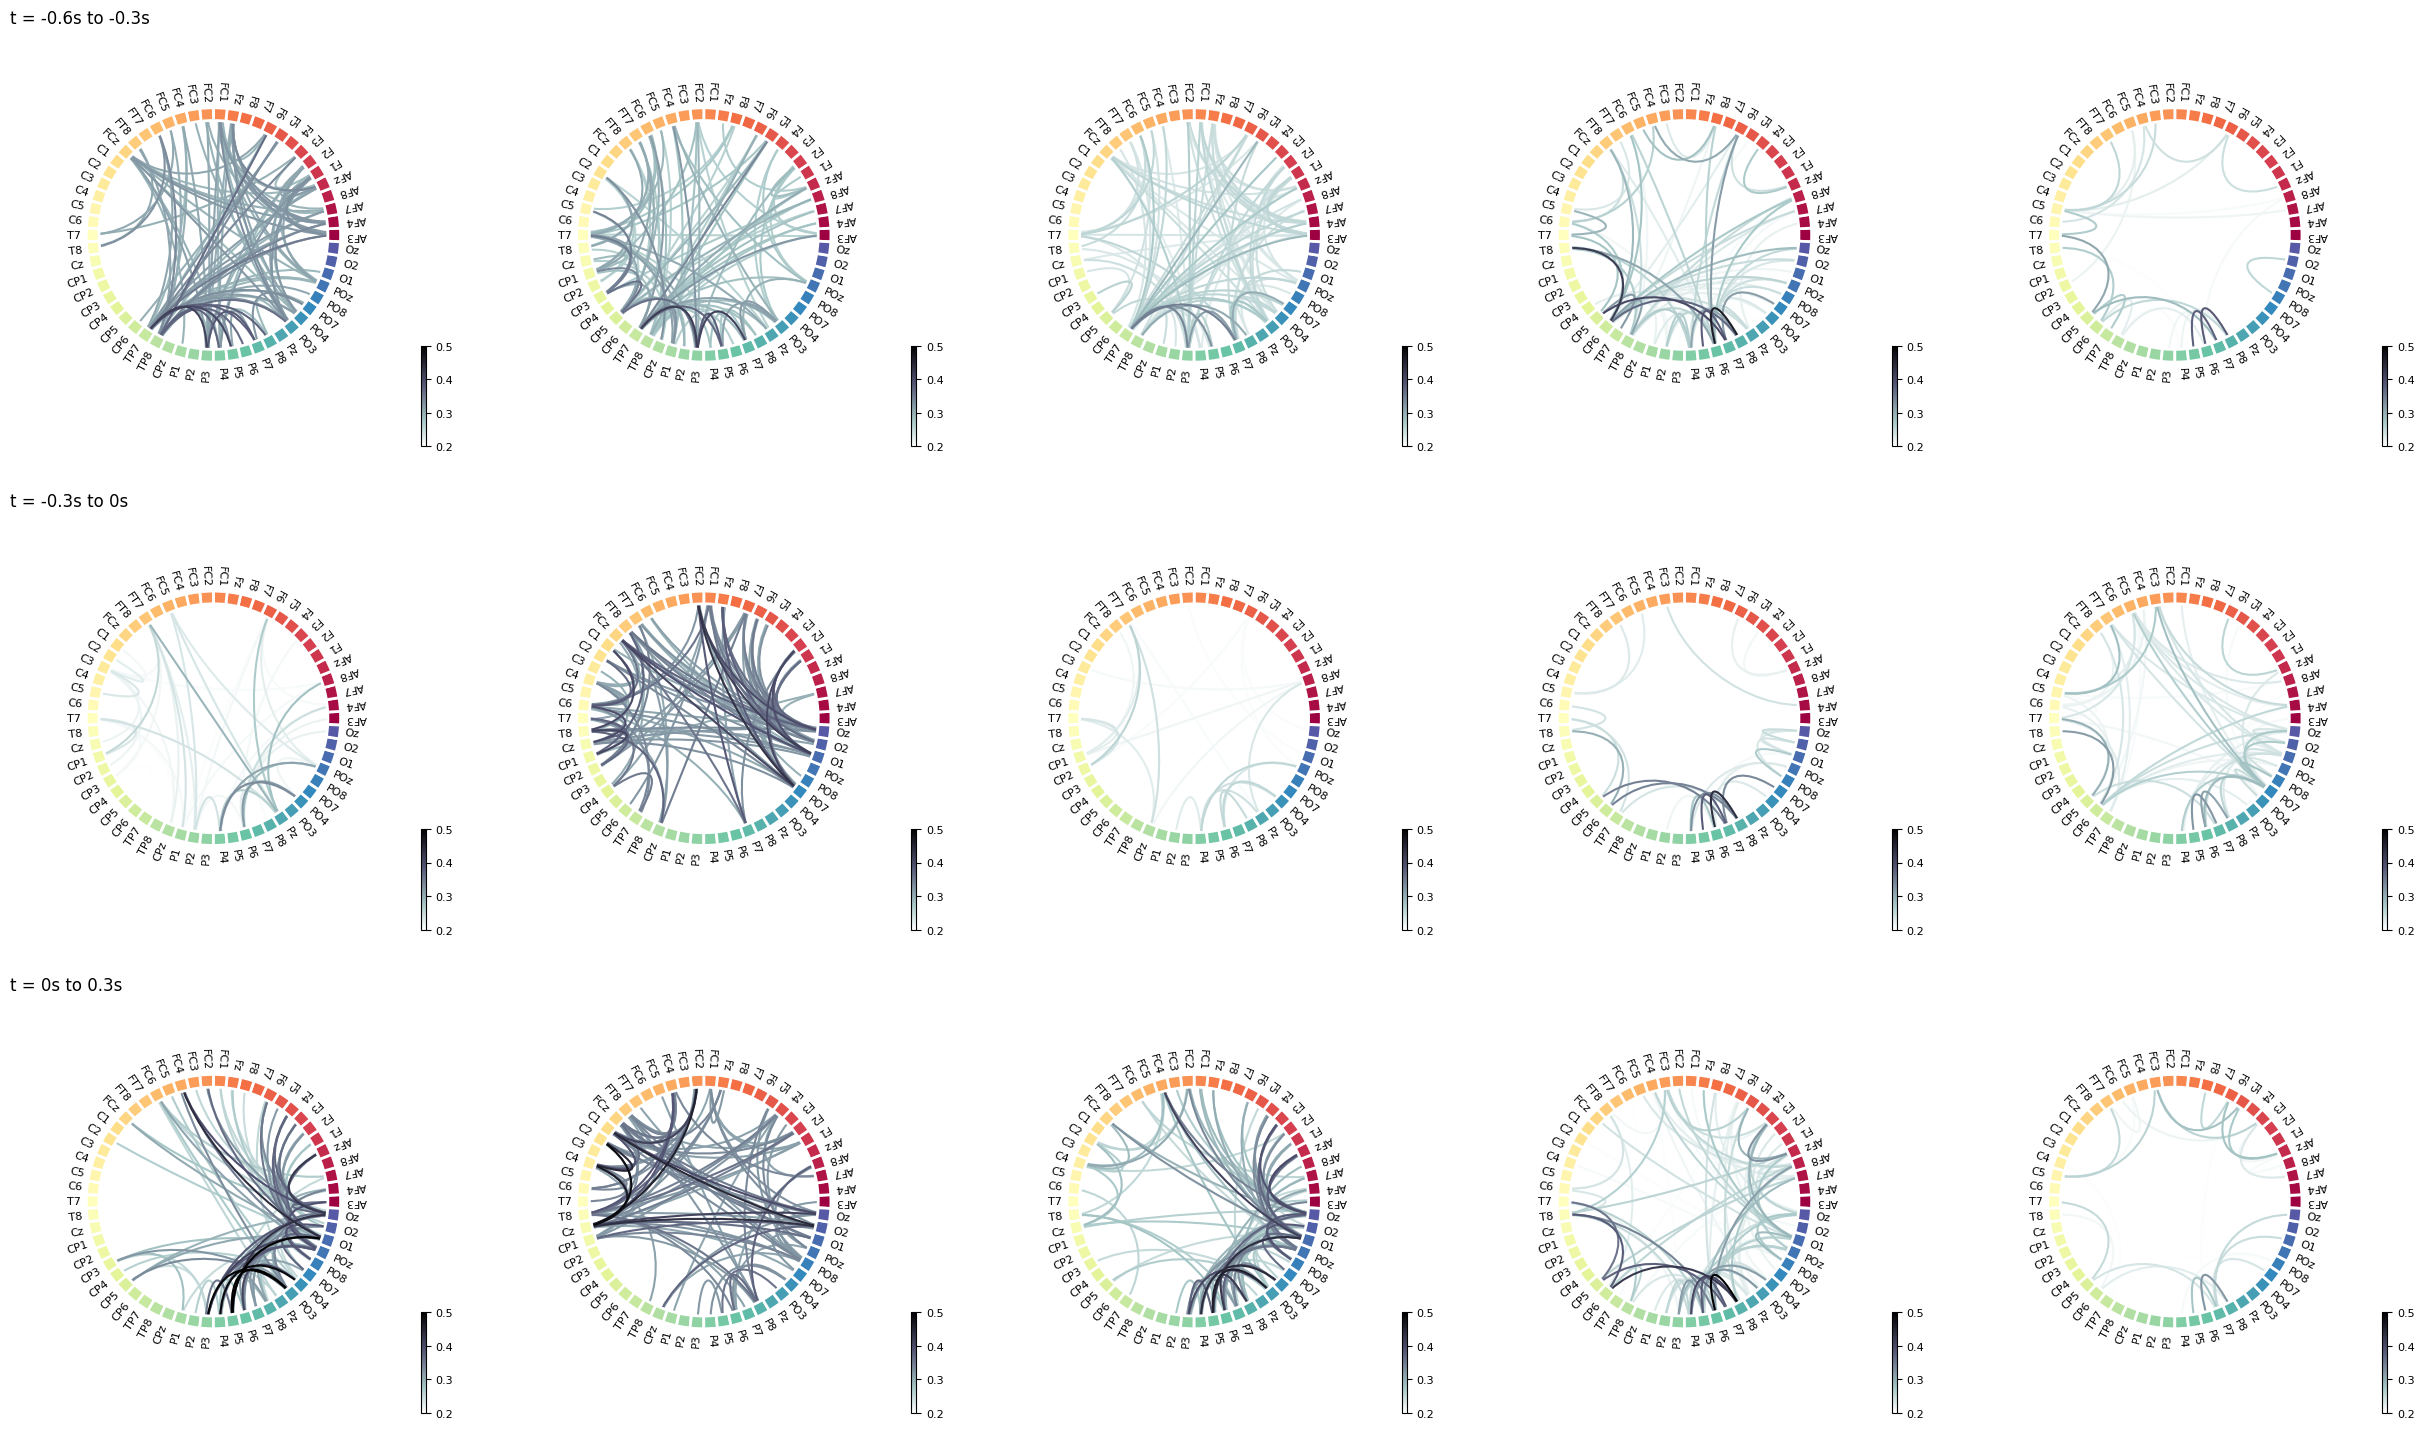

In [156]:
fig,axs = plt.subplots(len(intervals),len(bands),figsize=(len(bands)*5,len(intervals)*5),subplot_kw=dict(polar=True))
for k,i,ax in zip(range(len(intervals)),intervals,axs):
    for j,c,a in zip(range(5),con_sp_corr[k],ax):
        con.viz.plot_connectivity_circle(c, epochs.ch_names,n_lines=100,facecolor='w',textcolor='k',node_edgecolor='w',colormap='bone_r',ax=a,show=False,vmin=.2,vmax=.5)
        if j==0:
            a.set_title(f't = {i[0]}s to {i[1]}s',loc='left')
plt.tight_layout()

### Time-course Analysis

Noticing the Gamma-band coordination between fronto-central (FC) and parieto-occipital channels, we may be interested in the precise development of the connectivity between these two regions over time. To investigate the phenomenon, we adjust the channels in the `regions` variable above, and use MNE-Connectivity's wavelet analysis for time-resolved analysis.

Patterns we may notice here are:

1. A general increase of synchronization, particularly in lower frequencies, in reponse to the probe stimulus (somewhere around -800ms to -600ms).
2. Desynchronization in lower frequencies before the motor response (at 0ms).
3. Spike in Gamma synchronization between the two regions before the response.

In [195]:
con_time = {k:con.spectral_connectivity_epochs(epochs[k],method=measures,indices=ch_idx,mode='cwt_morlet',cwt_freqs=freqs,n_jobs=-1) for k in conditions}

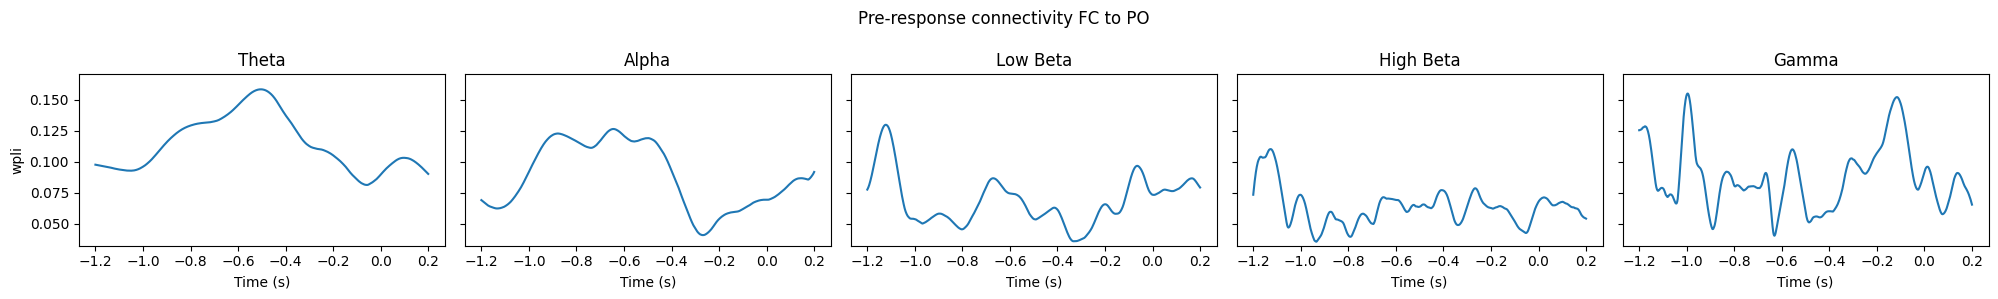

In [203]:
meas = 1
con_correct = [con_time["Correct==1"][meas].get_data()[:,from_to(freqs,bd),:].mean((0,1)) for bd in bands]
con_incorrect = [con_time["Correct==0"][meas].get_data()[:,from_to(freqs,bd),:].mean((0,1)) for bd in bands]
fig,axs = plt.subplots(1,len(bands),figsize=(4*len(bands),3),sharey=True)
for cor,inc,ax,b in zip(con_correct,con_incorrect,axs,["Theta","Alpha","Low Beta","High Beta","Gamma"]):
    dat = cor[500:-500]#/inc[500:-500]-1)*100
    ax.plot(epochs.times[500:-500],dat)
    ax.set_ylim(min(dat)*.8,max(dat)*1.1)
    ax.set_title(b)
    ax.set_xlabel("Time (s)")
axs[0].set_ylabel(measures[meas])
fig.suptitle(f"Pre-response connectivity FC to PO");
plt.tight_layout()